In [17]:
def salida(k,pesos,b):
    n=b
    for i in range(len(k)):
        n=n+(k[i]*pesos[i])
    if(n>=0):
        return 1
    else:
        return 0
def entrenar_percentron(datos_ent,pesos,b,lamda):
    errores=True
    epocas=0
    while errores:
        epocas=epocas+1
        print("Epoca: ",epocas)
        errores=False;
        for k,y in datos_ent.items():
            n=salida(k,pesos,b)
            if(n!=y):
                print("x1:",k[0],"x2:",k[1])
                errores=True
                e=(y-n)
                delta_b=(lamda*e)
                b=b+delta_b
                print("b: ",b,"e: ",e,"delta_b: ",delta_b)
                for i in range(len(k)):
                    delta_w=lamda*e*k[i]
                    pesos[i]=pesos[i]+delta_w
                    print("Peso",i,pesos[i])            
    return pesos,b
def clasificador(entrada,pesos,b):
    return salida(entrada,pesos,b)

In [18]:
#datos_ent={(0,0,1,0,0,1,0,0,1):1,(1,1,1,0,0,1,1,1,1):1,(1,1,1,0,1,0,0,1,0):1,
          #(0,0,0,0,0,0,0,0,0):0,(1,1,0,1,1,0,1,1,0):0,
          #(0,0,0,1,1,0,0,0,0):0,(0,0,0,1,0,1,1,0,1):0,
          #(1,1,1,1,1,1,1,1,1):0}
datos_ent={(0,0):0,(0,1):1,(1,0):1,(1,1):1}
#pesos=[.2,.6,.4,.2,.1,.4,.2,.1,.2]
pesos=[.2,.6]
b=-.5
lamda=.5
pesos,b=entrenar_percentron(datos_ent,pesos,b,lamda)
print("Pesos finales: ",pesos)
print("bias : ",b)
#print(clasificador((0,1,1,0,0,1,1,1,0),pesos,b))
print(clasificador((0,1), pesos, b))

Epoca:  1
x1: 1 x2: 0
b:  0.0 e:  1 delta_b:  0.5
Peso 0 0.7
Peso 1 0.6
Epoca:  2
x1: 0 x2: 0
b:  -0.5 e:  -1 delta_b:  -0.5
Peso 0 0.7
Peso 1 0.6
Epoca:  3
Pesos finales:  [0.7, 0.6]
bias :  -0.5
1


In [24]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score

In [30]:
#p=np.array([[0,0,0,0],
 #   [0,0,0,1],
  #  [0,0,1,0],
   # [0,0,1,1],
    #[0,1,0,0],
    #[0,1,0,1],
    #[0,1,1,0],
    #[0,1,1,1],
    #[1,0,0,0],
    #[1,0,0,1],
    #[1,0,1,0],
    #[1,0,1,1],
    #[1,1,0,0],
    #[1,1,0,1],
    #[1,1,1,0],
    #[1,1,1,1]])
#a=np.array([1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0])

p=np.array([
            [0,0],
            [0,1],
              [1,0],
             [1,1]])
a=np.array([[1,0], [0,0], [0,0], [0,1]])

# Red neuronal de tres capas ocultas: 3 capas ocultas con 10, 8 y 5 neuronas
#mlp = MLPClassifier(hidden_layer_sizes=(3,3), max_iter=400, random_state=42)
mlp = MLPClassifier(hidden_layer_sizes=(3,3), max_iter=2400, random_state=42)

# Entrenamiento
mlp.fit(p, a)

# Realizar predicciones
y_pred = mlp.predict(p)

# Evaluar el rendimiento del modelo
accuracy = accuracy_score(a, y_pred)

print(f"Precisión del modelo MLPClassifier: {accuracy:.2f}")

print("\nPredicciones (primeras 5):", y_pred[:15])
print("Valores reales (primeros 5):", a[:15])

Precisión del modelo MLPClassifier: 1.00

Predicciones (primeras 5): [[1 0]
 [0 0]
 [0 0]
 [0 1]]
Valores reales (primeros 5): [[1 0]
 [0 0]
 [0 0]
 [0 1]]


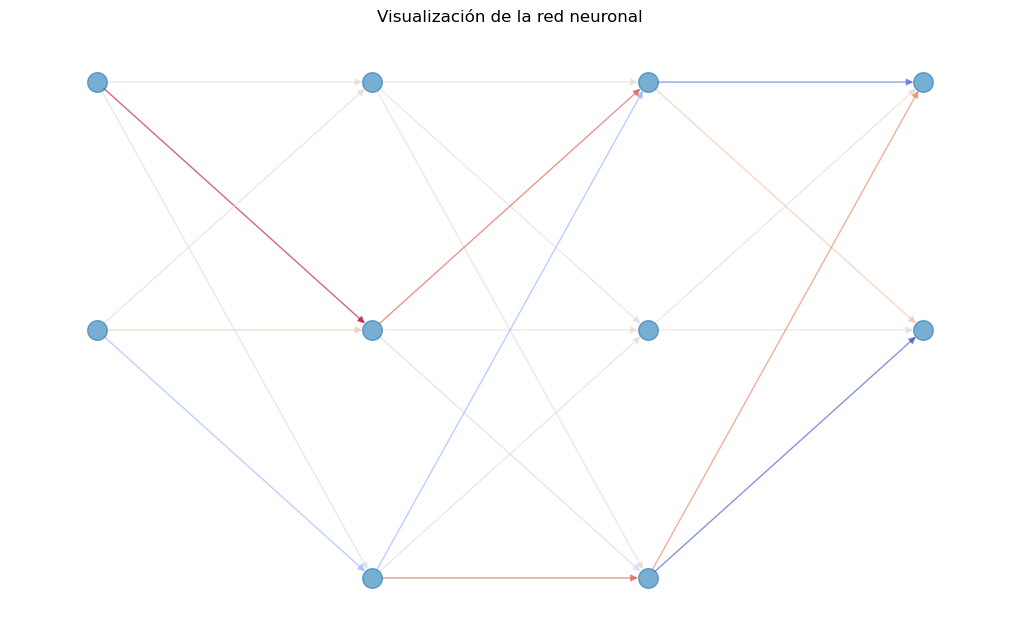

In [31]:
def plot_network(mlp):
    G = nx.DiGraph()
    layer_sizes = [mlp.coefs_[0].shape[0]] + [w.shape[1] for w in mlp.coefs_]
    total_layers = len(layer_sizes)

    # Crear nodos
    pos = {}
    for i, size in enumerate(layer_sizes):
        for j in range(size):
            G.add_node((i, j))
            pos[(i, j)] = (i, -j)

    # Crear aristas con pesos
    for i, w in enumerate(mlp.coefs_):
        for a in range(w.shape[0]):
            for b in range(w.shape[1]):
                G.add_edge((i, a), (i + 1, b), weight=w[a, b])

    # Dibujar grafo
    plt.figure(figsize=(10, 6))
    edges, weights = zip(*nx.get_edge_attributes(G, 'weight').items())
    nx.draw(G, pos, edgelist=edges, node_size=200, alpha=0.6,
            edge_color=weights, edge_cmap=plt.cm.coolwarm,
            with_labels=False, width=1)
    plt.title("Visualización de la red neuronal")
    plt.show()

plot_network(mlp)

Pesos entre capa 0 y 1:
(2, 3)
[[-6.24825600e-22  1.41838025e+00  1.68191688e+00]
 [ 2.45920603e-32 -1.30619162e+00 -1.68186652e+00]] 

Pesos entre capa 1 y 2:
(3, 3)
[[ 1.34321778e-09 -7.30008822e-03  6.10482940e-03]
 [ 1.28117717e+00 -7.64983846e-06 -8.01919436e-01]
 [-2.07477397e+00 -1.32663488e-10 -1.25386300e-51]] 

Pesos entre capa 2 y 3:
(3, 1)
[[-3.00512397e+00]
 [-5.21364900e-07]
 [-2.57656538e-01]] 

Sesgos de capa 1:
(3,)
[-9.68190297e-01  1.30570950e+00 -9.16107507e-05] 

Sesgos de capa 2:
(3,)
[-0.00072714 -0.41754172 -0.0023408 ] 

Sesgos de capa 3:
(1,)
[1.96154964] 



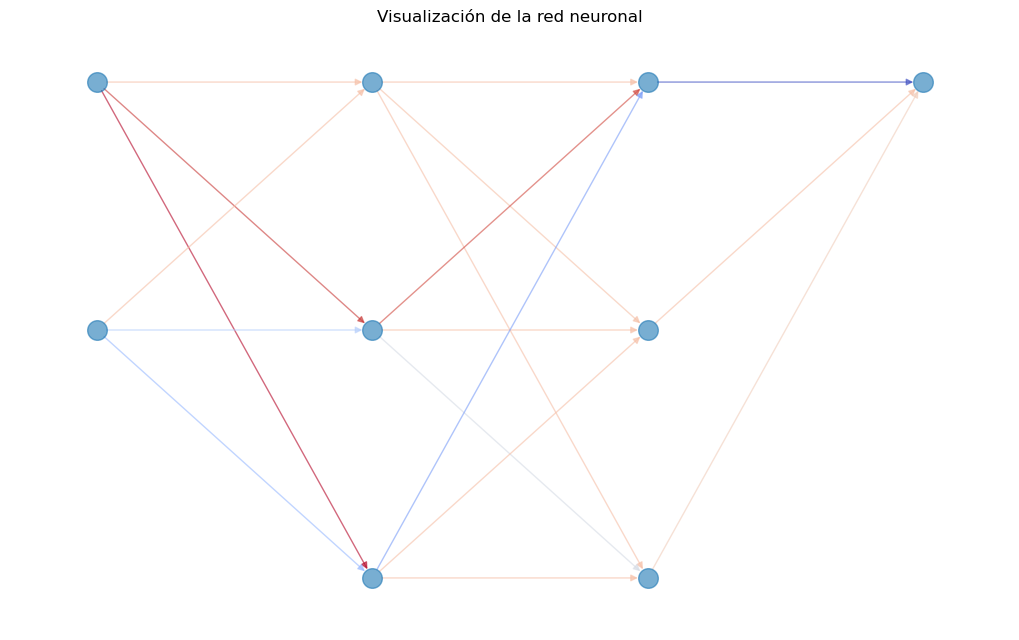

In [26]:
for i, pesos in enumerate(mlp.coefs_):
    print(f"Pesos entre capa {i} y {i+1}:")
    print(pesos.shape)
    print(pesos, "\n")

for i, bias in enumerate(mlp.intercepts_):
    print(f"Sesgos de capa {i+1}:")
    print(bias.shape)
    print(bias, "\n")
plot_network(mlp)